In [1]:
from pathlib import Path
import joblib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import ast

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import check_is_fitted

from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV


from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import MultiLabelBinarizer, label_binarize, OneHotEncoder, LabelEncoder
from collections import Counter
from sklearn.dummy import DummyRegressor

from collections import defaultdict

from xgboost import XGBRegressor

In [2]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [3]:
data_dir = Path('../../results')

#Load dfs
train = pd.read_csv(data_dir / 'train_clean.csv')
test = pd.read_csv(data_dir / 'test_clean.csv')

In [4]:
# Define target variables

y_train = train['averageRating']
y_test = test['averageRating']

In [5]:
# Create copies of the dataframes to manipulate
df_train = train.copy()
df_test = test.copy()

## Dummy Regressor
 variance (→ dummy regressor's MSE, i.e. the target variable's variance) and R2.



In [6]:
dummy_regressor = DummyRegressor(strategy="mean")
dummy_regressor.fit(df_train, y_train)
dummy_pred = dummy_regressor.predict(df_test)

In [7]:
# Calculate metrics
dummy_mse = mean_squared_error(y_test, dummy_pred)
dummy_r2 = r2_score(y_test, dummy_pred)

print(f"Dummy Regressor Performance:")
print(f"MSE: {dummy_mse:.3f}")
print(f"R-squared: {dummy_r2:.3f}")

"""
# Create scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, dummy_pred, alpha=0.6, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
"""

Dummy Regressor Performance:
MSE: 1.819
R-squared: -0.000


"\n# Create scatterplot\nplt.figure(figsize=(8, 6))\nplt.scatter(y_test, dummy_pred, alpha=0.6, s=30)\nplt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')\nplt.xlabel('True Values')\nplt.ylabel('Predicted Values')\nplt.title('True vs Predicted Values')\nplt.legend()\nplt.grid(True, alpha=0.3)\nplt.show()\n"

# Pre-Processing

Like we did for NN, we'll use fewer features than for the other models, in order to cut down on time for hyperparameter tuning.
- We'll only keep top 9 countries and regions
- delete hasAwards (corr to hasAwardsAndNominations)

In [8]:
def check_columns(train_df, test_df):
    train_cols = set(train_df.columns)
    test_cols = set(test_df.columns)
    if train_cols == test_cols:
        print("Train and test columns match.")
    else:
        print("Train and test columns DO NOT match.")
        print("Only in train:", train_cols - test_cols)
        print("Only in test:", test_cols - train_cols)

check_columns(df_train, df_test)


Train and test columns match.


In [9]:
# drop target variables + hasAwards
df_train.drop(columns=['rating', 'averageRating', 'hasAwards'], inplace=True) 
df_test.drop(columns=['rating', 'averageRating', 'hasAwards'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber', 'regions',
       'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio',
       'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [10]:
num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [11]:
num_cols, bool_cols, cat_cols #NB: cat_cols only contains titleType, this is for rating as a target

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'externalLinks',
        'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index(['titleType'], dtype='object'))

In [12]:
# Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

In [13]:
def clean_geo(geo, top_geo):
    """    Clean geographical data by replacing less common entries with 'Other'."""
    return [c if c in top_geo else "Other" for c in geo]

In [14]:
all_countries = [country for countries in df_train['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count

top_n_countries = 9
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)]) 

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

In [15]:
all_regions = [region for regions in df_train['regions'] for region in regions]
region_counts = Counter(all_regions) #Counter: dictionary 'country':count

top_n_regions = 9
top_regions = set([region for region, _ in region_counts.most_common(top_n_regions)])

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

In [16]:
# Custom transformer for MultiLabelBinarizer
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self
    
    def transform(self, X):
        return self.mlb.transform(X)
    
    def get_feature_names_out(self, input_features=None):
        'Return feature names for output features'
        check_is_fitted(self.mlb)
        return np.array([f"mlb__{label}" for label in self.mlb.classes_])

In [17]:
def build_preprocessor(num_cols, bool_cols, cat_cols):
    return ColumnTransformer(
        transformers=[
            ('num', 'passthrough', num_cols), #TREES: NO SCALING NEEDED
            ('bool', 'passthrough', bool_cols),
            ('cat', OneHotEncoder(), cat_cols),  # No need for drop='first': RF handles redundant feats
            ('countries', MultiLabelBinarizerTransformer(), 'country_cleaned'),
            ('genres', MultiLabelBinarizerTransformer(), 'genres'),
            ('regions', MultiLabelBinarizerTransformer(), 'region_cleaned')
        ]
    )

# Hyperparameter Tuning

In [18]:
pipeline= Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', XGBRegressor(random_state=42))
])

In [37]:
param_grid_100 = {
    'clf__n_estimators': [100],
    'clf__max_depth': [3, 6, 9],
    'clf__learning_rate': [0.05, 0.1, 0.3],
    'clf__min_child_weight': [1, 2, 3, 4], # Similar to 'min_samples_leaf' in Random Forest
    'clf__gamma': [0, 0.1, 0.5, 1], # minimum reduction in loss required to make a split
    'clf__reg_alpha': [0, 0.01, 0.1],  # L1 regularization
    'clf__reg_lambda': [1, 1.5, 2, 5] # larger for L2 for xgboost
}

param_grid_300 = {
    'clf__n_estimators': [300],
    'clf__max_depth': [3, 6, 9],
    'clf__learning_rate': [0.05, 0.1, 0.3],
    'clf__min_child_weight': [1, 2, 3, 4], # Similar to 'min_samples_leaf' in Random Forest
    'clf__gamma': [0, 0.1, 0.5, 1], # minimum reduction in loss required to make a split
    'clf__reg_alpha': [0, 0.01, 0.1],  # L1 regularization
    'clf__reg_lambda': [1, 1.5, 2, 5] # larger for L2 for xgboost
}

param_grid_500 = {
    'clf__n_estimators': [500],
    'clf__max_depth': [3, 6, 9],
    'clf__learning_rate': [0.05, 0.1, 0.3],
    'clf__min_child_weight': [1, 2, 3, 4], # Similar to 'min_samples_leaf' in Random Forest
    'clf__gamma': [0, 0.1, 0.5, 1], # minimum reduction in loss required to make a split
    'clf__reg_alpha': [0, 0.01, 0.1],  # L1 regularization
    'clf__reg_lambda': [1, 1.5, 2, 5] # larger for L2 for xgboost
}

In [38]:
random_search_100 = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid_100,
    n_iter=100,
    cv=3,
    scoring=['neg_mean_squared_error', 'r2'],
    refit='r2',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_100.fit(df_train, y_train)

print(f"BEST MODEL:")
best_index_100 = random_search_100.best_index_
val_mse_100 = -random_search_100.cv_results_['mean_test_neg_mean_squared_error'][best_index_100]
train_mse_100 = -random_search_100.cv_results_['mean_train_neg_mean_squared_error'][best_index_100]
train_r2_100 = random_search_100.cv_results_['mean_train_r2'][best_index_100]

print(f"Validation R²: {random_search_100.best_score_:.3f}; vs R² on train: {train_r2_100:.3f}")
print(f"MSE on validation: {val_mse_100:.3f}; vs MSE on train: {train_mse_100:.3f}")
print(f"Best parameters: {random_search_100.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL:
Validation R²: 0.378; vs R² on train: 0.542
MSE on validation: 1.130; vs MSE on train: 0.833
Best parameters: {'clf__reg_lambda': 1, 'clf__reg_alpha': 0, 'clf__n_estimators': 100, 'clf__min_child_weight': 1, 'clf__max_depth': 9, 'clf__learning_rate': 0.1, 'clf__gamma': 0.1}


In [39]:
random_search_300 = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid_300,
    n_iter=100,
    cv=3,
    scoring=['neg_mean_squared_error', 'r2'],
    refit='r2',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_300.fit(df_train, y_train)

print(f"BEST MODEL (300 estimators):")
best_index_300 = random_search_300.best_index_
val_mse_300 = -random_search_300.cv_results_['mean_test_neg_mean_squared_error'][best_index_300]
train_mse_300 = -random_search_300.cv_results_['mean_train_neg_mean_squared_error'][best_index_300]
train_r2_300 = random_search_300.cv_results_['mean_train_r2'][best_index_300]

print(f"Validation R²: {random_search_300.best_score_:.3f}; vs R² on train: {train_r2_300:.3f}")
print(f"MSE on validation: {val_mse_300:.3f}; vs MSE on train: {train_mse_300:.3f}")
print(f"Best parameters: {random_search_300.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL (300 estimators):
Validation R²: 0.394; vs R² on train: 0.699
MSE on validation: 1.101; vs MSE on train: 0.547
Best parameters: {'clf__reg_lambda': 1.5, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 300, 'clf__min_child_weight': 1, 'clf__max_depth': 9, 'clf__learning_rate': 0.1, 'clf__gamma': 0}


In [40]:
random_search_500 = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid_500,
    n_iter=100,
    cv=3,
    scoring=['neg_mean_squared_error', 'r2'],
    refit='r2',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_500.fit(df_train, y_train)

print(f"BEST MODEL (500 estimators):")
best_index_500 = random_search_500.best_index_
val_mse_500 = -random_search_500.cv_results_['mean_test_neg_mean_squared_error'][best_index_500]
train_mse_500 = -random_search_500.cv_results_['mean_train_neg_mean_squared_error'][best_index_500]
train_r2_500 = random_search_500.cv_results_['mean_train_r2'][best_index_500]

print(f"Validation R²: {random_search_500.best_score_:.3f}; vs R² on train: {train_r2_500:.3f}")
print(f"MSE on validation: {val_mse_500:.3f}; vs MSE on train: {train_mse_500:.3f}")
print(f"Best parameters: {random_search_500.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL (500 estimators):
Validation R²: 0.397; vs R² on train: 0.759
MSE on validation: 1.097; vs MSE on train: 0.439
Best parameters: {'clf__reg_lambda': 5, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 2, 'clf__max_depth': 9, 'clf__learning_rate': 0.1, 'clf__gamma': 0}


In [41]:
cv_results_100 = pd.DataFrame(random_search_100.cv_results_)
cv_results_100['overfitting_gap'] = cv_results_100['mean_train_r2'] - cv_results_100['mean_test_r2']

cv_results_300 = pd.DataFrame(random_search_300.cv_results_)
cv_results_300['overfitting_gap'] = cv_results_300['mean_train_r2'] - cv_results_300['mean_test_r2']

cv_results_500 = pd.DataFrame(random_search_500.cv_results_)
cv_results_500['overfitting_gap'] = cv_results_500['mean_train_r2'] - cv_results_500['mean_test_r2']

In [ ]:
"""
cv_results_100.to_csv(data_dir / "cv_results_xgb_100.csv", index=False)
cv_results_300.to_csv(data_dir / "cv_results_xgb_300.csv", index=False)
cv_results_500.to_csv(data_dir / "cv_results_xgb_500.csv", index=False)
"""

In [44]:
pd.set_option("display.max_colwidth", None)

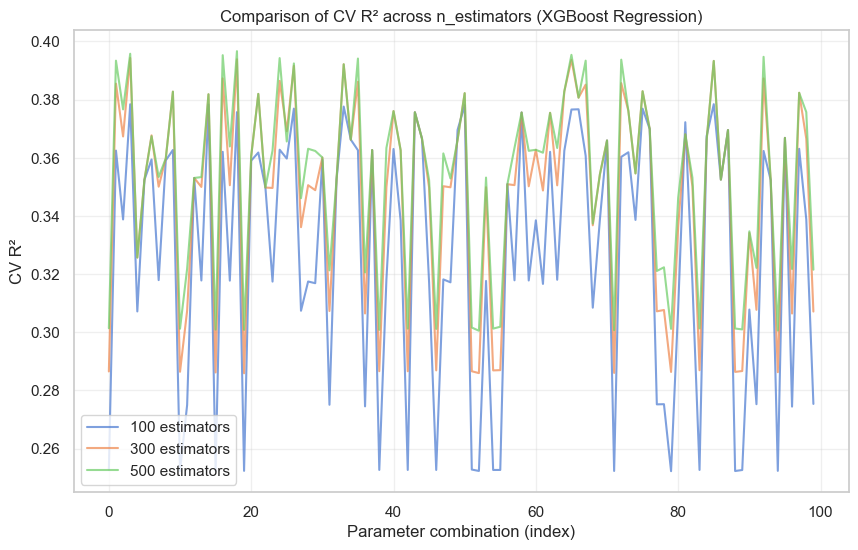

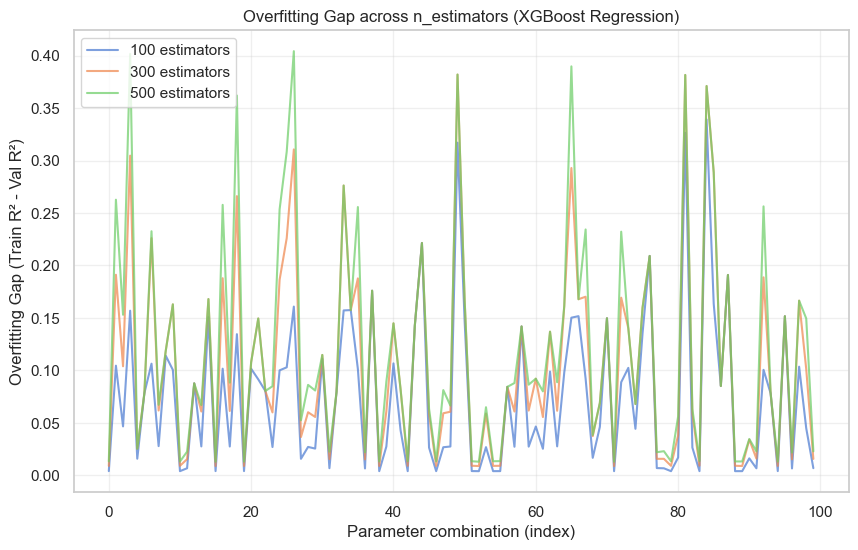

In [43]:
# First plot - CV R² scores
plt.figure(figsize=(10, 6))
plt.plot(cv_results_100.index, cv_results_100["mean_test_r2"], 
         label="100 estimators", alpha=0.7)
plt.plot(cv_results_300.index, cv_results_300["mean_test_r2"], 
         label="300 estimators", alpha=0.7)
plt.plot(cv_results_500.index, cv_results_500["mean_test_r2"], 
         label="500 estimators", alpha=0.7)
plt.xlabel("Parameter combination (index)")
plt.ylabel("CV R²")
plt.title("Comparison of CV R² across n_estimators (XGBoost Regression)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Second plot - Overfitting gap
plt.figure(figsize=(10, 6))
plt.plot(cv_results_100.index, cv_results_100["overfitting_gap"], 
         label="100 estimators", alpha=0.7)
plt.plot(cv_results_300.index, cv_results_300["overfitting_gap"], 
         label="300 estimators", alpha=0.7)
plt.plot(cv_results_500.index, cv_results_500["overfitting_gap"], 
         label="500 estimators", alpha=0.7)
plt.xlabel("Parameter combination (index)")
plt.ylabel("Overfitting Gap (Train R² - Val R²)")
plt.title("Overfitting Gap across n_estimators (XGBoost Regression)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

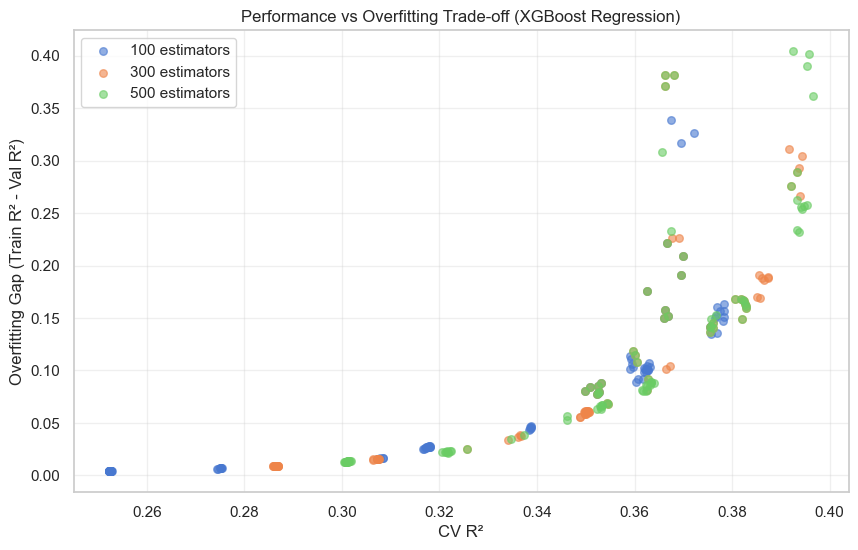

In [58]:
plt.figure(figsize=(10, 6))

plt.scatter(cv_results_100["mean_test_r2"], cv_results_100["overfitting_gap"], 
           alpha=0.6, label="100 estimators", s=30)
plt.scatter(cv_results_300["mean_test_r2"], cv_results_300["overfitting_gap"], 
           alpha=0.6, label="300 estimators", s=30)
plt.scatter(cv_results_500["mean_test_r2"], cv_results_500["overfitting_gap"], 
           alpha=0.6, label="500 estimators", s=30)

plt.xlabel("CV R²")
plt.ylabel("Overfitting Gap (Train R² - Val R²)")
plt.title("Performance vs Overfitting Trade-off (XGBoost Regression)")
plt.legend()
plt.grid(True, alpha=0.3)

# Adjust limits for regression R² values (typically 0 to 1)
#plt.xlim(left=0, right=0.5)
#plt.ylim(bottom=0)  # R² gap should be positive (overfitting)
#plt.gca().set_aspect('equal', adjustable='box')

plt.show()

We can distinguish two slightly different exponential trends.  

In [66]:
cv_results_500.sort_values(
    by=["mean_test_r2", "overfitting_gap"], 
    ascending=[False, True]
).head(25)[['params','mean_train_r2', 'mean_test_r2', 'overfitting_gap']]

,params,mean_train_r2,mean_test_r2,overfitting_gap
18,"{'clf__reg_lambda': 5, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 2, 'clf__max_depth': 9, 'clf__learning_rate': 0.1, 'clf__gamma': 0}",0.758678,0.396666,0.362012
3,"{'clf__reg_lambda': 1.5, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 500, 'clf__min_child_weight': 1, 'clf__max_depth': 9, 'clf__learning_rate': 0.1, 'clf__gamma': 0}",0.797448,0.395780,0.401668
65,"{'clf__reg_lambda': 2, 'clf__reg_alpha': 0, 'clf__n_estimators': 500, 'clf__min_child_weight': 2, 'clf__max_depth': 9, 'clf__learning_rate': 0.1, 'clf__gamma': 0}",0.785220,0.395407,0.389812
16,"{'clf__reg_lambda': 2, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 500, 'clf__min_child_weight': 2, 'clf__max_depth': 9, 'clf__learning_rate': 0.05, 'clf__gamma': 0}",0.653098,0.395292,0.257807
92,"{'clf__reg_lambda': 2, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 500, 'clf__min_child_weight': 1, 'clf__max_depth': 9, 'clf__learning_rate': 0.05, 'clf__gamma': 0.1}",0.651075,0.394723,0.256352
24,"{'clf__reg_lambda': 2, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 2, 'clf__max_depth': 9, 'clf__learning_rate': 0.05, 'clf__gamma': 0.1}",0.647767,0.394288,0.253480
35,"{'clf__reg_lambda': 1, 'clf__reg_alpha': 0, 'clf__n_estimators': 500, 'clf__min_child_weight': 4, 'clf__max_depth': 9, 'clf__learning_rate': 0.05, 'clf__gamma': 0.1}",0.649852,0.394131,0.255721
72,"{'clf__reg_lambda': 5, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 9, 'clf__learning_rate': 0.05, 'clf__gamma': 0.1}",0.625965,0.393744,0.232221
1,"{'clf__reg_lambda': 1, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 9, 'clf__learning_rate': 0.05, 'clf__gamma': 0}",0.656114,0.393401,0.262713
67,"{'clf__reg_lambda': 5, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 500, 'clf__min_child_weight': 1, 'clf__max_depth': 9, 'clf__learning_rate': 0.05, 'clf__gamma': 0}",0.627739,0.393400,0.234339


# Model

We choose as a compromise in the variance- bias trade-off:

75	{'clf__reg_lambda': 5, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 2, 'clf__max_depth': 9, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5}	0.542659	0.382886	0.159773

In [67]:
params_75 = cv_results_500.loc[75, 'params']
print(params_75)

pipeline.set_params(**params_75)
pipeline.fit(df_train, y_train)

{'clf__reg_lambda': 5, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 2, 'clf__max_depth': 9, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5}


,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bool', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
joblib.dump(pipeline, data_dir / 'xgb_regression.pkl')

['..\\..\\results\\xgb_regression.pkl']

In [68]:
y_pred = pipeline.predict(df_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"MSE: {mse:.3f}")
print(f"R-squared: {r2:.3f}")

Model Performance:
MSE: 1.108
R-squared: 0.391


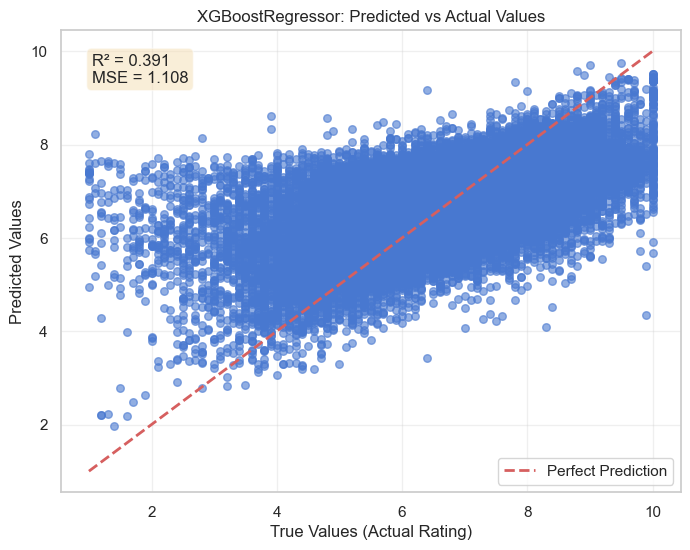

In [71]:
# Create scatterplot comparing predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Values (Actual Rating)')
plt.ylabel('Predicted Values')
plt.title('XGBoostRegressor: Predicted vs Actual Values')
plt.legend()
plt.grid(True, alpha=0.3)

# Add R² and MSE to the plot
plt.text(0.05, 0.95, f'R² = {r2:.3f}\nMSE = {mse:.3f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

The R2 is better than the mean validation R2 (0.391 vs 0.383), but it is nevertheless moderately overfitted (avg train R2: 0.543). The model outperforms the baseline, the results are mediocre, as we could expect from the classification task.

# Trying the best model

In [19]:
best_params = {'clf__reg_lambda': 5, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 2, 'clf__max_depth': 9, 'clf__learning_rate': 0.1, 'clf__gamma': 0}

In [20]:
pipeline.set_params(**best_params)
pipeline.fit(df_train, y_train)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bool', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
y_pred = pipeline.predict(df_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"MSE: {mse:.3f}")
print(f"R-squared: {r2:.3f}")

Model Performance:
MSE: 1.075
R-squared: 0.409


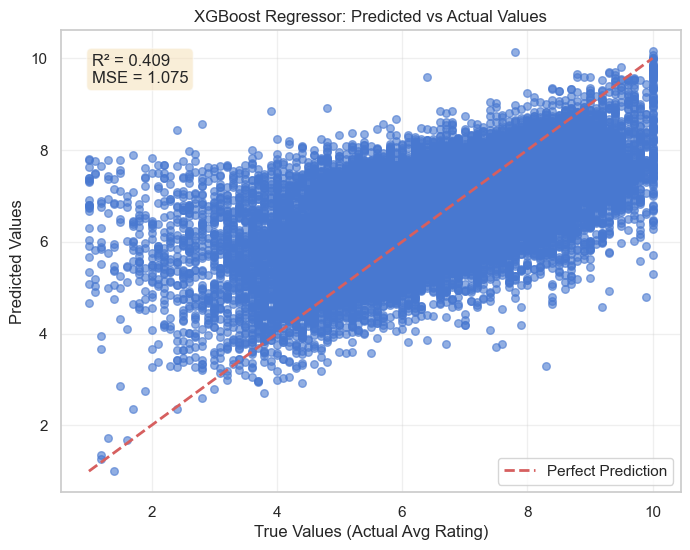

In [22]:
# Create scatterplot comparing predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Values (Actual Avg Rating)')
plt.ylabel('Predicted Values')
plt.title('XGBoost Regressor: Predicted vs Actual Values')
plt.legend()
plt.grid(True, alpha=0.3)

# Add R² and MSE to the plot
plt.text(0.05, 0.95, f'R² = {r2:.3f}\nMSE = {mse:.3f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

better than the other model

In [23]:
from scipy.stats import pearsonr, spearmanr
pearson_corr, _ = pearsonr(y_test, y_pred)
spearman_corr, _ = spearmanr(y_test, y_pred)

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

Pearson correlation: 0.640
Spearman correlation: 0.637
